## Medidas de centralidad y prestigio proyecto

In [1]:
# Librerias que vamos a usar
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community.quality import modularity
from sklearn.metrics import normalized_mutual_info_score
import community
import community.community_louvain as cl


In [2]:
# Nodos y arcos de la red
nodos = pd.read_excel('https://raw.githubusercontent.com/jhon1142/Proyeco-redes-sociales/main/Nodos..xlsx')

arcos = pd.read_excel('https://raw.githubusercontent.com/jhon1142/Proyeco-redes-sociales/main/Arcos..xlsx')
nodos


,Id,Headquarters Location,Operating Status,Company Type,Number of Investments,Number of Lead Investments,Number of Diversity Investments,Number of Exits,Number of Lead Investors,Number of Investors,...,Total Funding Amount,Total Funding Amount Currency,Total Funding Amount Currency (in USD),Number of Events,SEMrush - Monthly Visits,SEMrush - Average Visits (6 months),SEMrush - Visit Duration,Aberdeen - IT Spend,Aberdeen - IT Spend Currency,Aberdeen - IT Spend Currency (in USD)
0,Tencent,"Shenzhen, Guangdong, China",Active,For Profit,693.0,375.0,15.0,125.0,1.0,4.0,...,1.257677e+10,USD,1.257677e+10,22.0,"4,085,844","3,553,184",600.0,NaN,NaN,NaN
1,Warburg Pincus,"New York, New York, United States",Active,NaN,433.0,286.0,22.0,131.0,NaN,NaN,...,3.802820e+07,USD,3.802820e+07,NaN,34.635,"34,033.67",392.0,53801.0,USD,53801.0
2,Twitter,"San Francisco, California, United States",Active,For Profit,10.0,2.0,1.0,3.0,9.0,37.0,...,4.430192e+09,USD,4.430192e+09,77.0,"6,026,399,205","3,104,998,131.33",942.0,NaN,NaN,NaN
3,Ubisoft,"Montreuil-sous-bois, Ile-de-France, France",Active,For Profit,9.0,NaN,NaN,1.0,1.0,4.0,...,7.706506e+08,USD,7.706506e+08,16.0,"32,820,567","27,881,933.83",392.0,NaN,NaN,NaN
4,WeWork,"New York, New York, United States",Active,For Profit,9.0,6.0,4.0,2.0,11.0,24.0,...,2.159578e+10,USD,2.159578e+10,120.0,"2,646,155","2,483,475.83",280.0,343977.0,USD,343977.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2206,Activation Capital,NaN,Active,NaN,1.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2207,Gavi,"Moritzburg, Sachsen, Germany",Active,For Profit,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4070569.0,USD,4070569.0
2208,BF Holdings,"Dudley, Dudley, United Kingdom",Closed,For Profit,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2209,GO Virginia,NaN,Active,NaN,2.0,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.495,NaN,0.0,NaN,NaN,NaN


In [3]:
arcos

,Source,Target
0,01 Advisors,Electric
1,01 Advisors,Origin
2,17Capital LLP,NewSpring
3,1kx,Arweave
4,1kx,Rarible
...,...,...
4182,Zomato,Shiprocket
4183,Zoom,Genesys
4184,Zoom,Theta Lake
4185,Zoom,monday.com


In [4]:
#limpieza
nodos_clean = nodos.copy()

# 1) Eliminar columnas redundantes
nodos_clean = nodos_clean.drop(columns=['Label', 'Operating Status'], errors='ignore')

# 2) Headquarters Location → Country
nodos_clean['Country'] = (
    nodos_clean['Headquarters Location']
    .fillna('Unknown')
    .apply(lambda x: x.split(',')[-1].strip())
)
nodos_clean = nodos_clean.drop(columns=['Headquarters Location'], errors='ignore')

# 3) Company Type (NaN → Unknown)
nodos_clean['Company Type'] = nodos_clean['Company Type'].fillna('Unknown')

# 4) Industry Groups → sector principal
nodos_clean['Industry Group Main'] = (
    nodos_clean['Industry Groups']
    .fillna('Other')
    .apply(lambda x: x.split(',')[0].strip())
)
nodos_clean = nodos_clean.drop(columns=['Industry Groups'], errors='ignore')

# 5) Number of Investments (NaN → 0)
nodos_clean['Number of Investments'] = nodos_clean['Number of Investments'].fillna(0)

# 6) Marcar si hay información de funding
nodos_clean['Has Funding Info'] = nodos_clean['Total Funding Amount Currency (in USD)'].notna()

# 7) Funding por inversión (evitar división por cero)
nodos_clean['Funding per Investment'] = (
    nodos_clean['Total Funding Amount Currency (in USD)'] /
    nodos_clean['Number of Investments'].replace(0, np.nan)
)

# 8) Log del funding (opcional)
nodos_clean['Log Total Funding'] = np.log1p(
    nodos_clean['Total Funding Amount Currency (in USD)']
)

# Vista previa del resultado
nodos_clean

,Id,Company Type,Number of Investments,Number of Lead Investments,Number of Diversity Investments,Number of Exits,Number of Lead Investors,Number of Investors,Industries,Number of Funding Rounds,...,SEMrush - Average Visits (6 months),SEMrush - Visit Duration,Aberdeen - IT Spend,Aberdeen - IT Spend Currency,Aberdeen - IT Spend Currency (in USD),Country,Industry Group Main,Has Funding Info,Funding per Investment,Log Total Funding
0,Tencent,For Profit,693.0,375.0,15.0,125.0,1.0,4.0,"Advertising, Internet, Online Games, Online Po...",6.0,...,"3,553,184",600.0,NaN,NaN,NaN,China,Advertising,True,1.814830e+07,23.255117
1,Warburg Pincus,Unknown,433.0,286.0,22.0,131.0,NaN,NaN,"Finance, Financial Services, Venture Capital",1.0,...,"34,033.67",392.0,53801.0,USD,53801.0,United States,Financial Services,True,8.782495e+04,17.453839
2,Twitter,For Profit,10.0,2.0,1.0,3.0,9.0,37.0,"Blogging Platforms, Messaging, SMS, Social Media",19.0,...,"3,104,998,131.33",942.0,NaN,NaN,NaN,United States,Content and Publishing,True,4.430192e+08,22.211709
3,Ubisoft,For Profit,9.0,NaN,NaN,1.0,1.0,4.0,"Media and Entertainment, Publishing, Video Games",3.0,...,"27,881,933.83",392.0,NaN,NaN,NaN,France,Content and Publishing,True,8.562785e+07,20.462746
4,WeWork,For Profit,9.0,6.0,4.0,2.0,11.0,24.0,"Commercial Real Estate, Coworking, Property De...",21.0,...,"2,483,475.83",280.0,343977.0,USD,343977.0,United States,Real Estate,True,2.399532e+09,23.795764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2206,Activation Capital,Unknown,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Unknown,Other,False,NaN,NaN
2207,Gavi,For Profit,0.0,NaN,NaN,NaN,NaN,NaN,"Consumer Goods, Grocery, Wholesale, Wine And S...",NaN,...,NaN,NaN,4070569.0,USD,4070569.0,Germany,Commerce and Shopping,False,NaN,NaN
2208,BF Holdings,For Profit,1.0,NaN,NaN,NaN,NaN,NaN,Manufacturing,NaN,...,NaN,NaN,NaN,NaN,NaN,United Kingdom,Manufacturing,False,NaN,NaN
2209,GO Virginia,Unknown,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,Unknown,Other,False,NaN,NaN


In [5]:
# Construir red
G = nx.DiGraph()

# agregar todos los nodos del archivo de nodos
G.add_nodes_from(nodos_clean["Id"].tolist())

# luego agregar arcos
G.add_edges_from(arcos[["Source", "Target"]].itertuples(index=False, name=None))

# atributos
atributos = nodos_clean.set_index("Id").to_dict("index")
nx.set_node_attributes(G, atributos)

In [6]:
#Numero de nodos
print(G.number_of_nodes())
#Numero de arcos
print(G.number_of_edges())

2218
4187


In [7]:
import networkx as nx

# Calcular grado total (entrada + salida)
grado = (
    arcos['Source'].value_counts()
    .add(arcos['Target'].value_counts(), fill_value=0)
)

# Id del nodo más conectado
id_max = grado.idxmax()

print("Nodo más conectado:")
print("Id:", id_max)


Nodo más conectado:
Id: Tiger Global Management


In [8]:
#Centralidad Eigenvector
Eige_centralidad = nx.eigenvector_centrality(G)
#Nodo con mayor centralidad
id_max = max(Eige_centralidad, key=Eige_centralidad.get)

print("Nodo con mayor Eigenvector Centrality:")
print("Id:", id_max)
print("Valor:", Eige_centralidad[id_max])

Nodo con mayor Eigenvector Centrality:
Id: Uber
Valor: 0.39995016088210233


In [9]:
#Betweenness Top 10
import pandas as pd

bet = nx.betweenness_centrality(G)

bet_df = pd.DataFrame(
    bet.items(),
    columns=['Id', 'Betweenness']
)

bet_df.sort_values(
    by='Betweenness',
    ascending=False
).head(10)

,Id,Betweenness
1382,Animoca Brands,0.000080
0,Tencent,0.000074
3,Ubisoft,0.000044
1385,Digital Currency Group,0.000033
774,Mirae Asset Global Investments,0.000030
1771,Didi,0.000028
1423,Google,0.000027
1754,Bolt,0.000023
52,Silver Lake,0.000022
50,SoftBank,0.000021


In [ ]:
centralidades = pd.DataFrame({
    'Id': G.nodes(),
    'Eigenvector': nx.eigenvector_centrality(G, max_iter=1000).values(),
    'Betweenness': nx.betweenness_centrality(G).values()
})

centralidades.sort_values(
    by='Betweenness',
    ascending=False
).head(10)


,Id,Eigenvector,Betweenness
1382,Animoca Brands,5.216925e-02,0.000080
0,Tencent,7.320095e-09,0.000074
3,Ubisoft,2.032136e-07,0.000044
1385,Digital Currency Group,7.320095e-09,0.000033
774,Mirae Asset Global Investments,5.216742e-02,0.000030
1771,Didi,5.886522e-07,0.000028
1423,Google,2.911843e-07,0.000027
1754,Bolt,4.714659e-06,0.000023
52,Silver Lake,3.692437e-09,0.000022
50,SoftBank,3.692437e-09,0.000021


La centralidad de intermediación presenta una distribución altamente sesgada, donde la mayoría de los nodos exhiben valores cercanos a cero, mientras que un reducido subconjunto actúa como puente entre comunidades de la red.

Tal como se observa en la Tabla, únicamente un conjunto reducido de inversionistas presenta valores significativos de centralidad de intermediación, confirmando la existencia de nodos puente que conectan distintas comunidades dentro de la red.

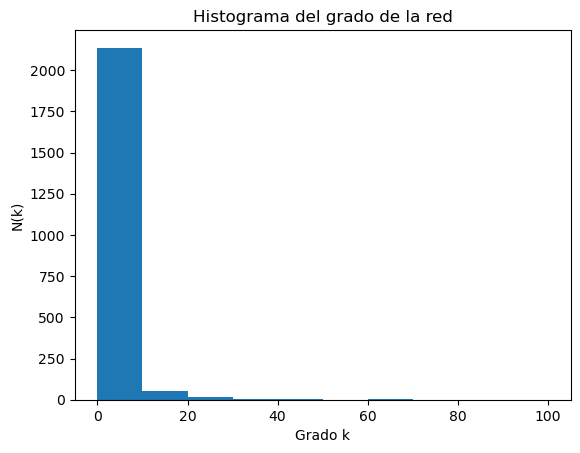

In [ ]:
#Grado
grado=[]
for node in G.nodes():
    grado.append(G.degree(node))

a=plt.hist(grado)
plt.title('Histograma del grado de la red')
plt.xlabel ("Grado k")
plt.ylabel ("N(k)")
plt.show()

In [10]:
#Densidad (dirigida)
densidad = nx.number_of_edges(G) / (nx.number_of_nodes(G) * (nx.number_of_nodes(G) - 1))
densidad = round(densidad, 3)
densidad

0.001

In [11]:
#asortatividad
asortatividad =nx.degree_assortativity_coefficient(G)
asortatividad =round(asortatividad ,4)
asortatividad

0.1037

La red presenta una asortatividad positiva moderada (r = 0.1125), lo que sugiere una ligera tendencia de los inversionistas a relacionarse con actores de conectividad similar, sin evidenciar una estructura fuertemente segregada.

In [12]:
# promedio de out-degree
gradoProm_out = sum(dict(G.out_degree()).values()) / G.number_of_nodes()
print(round(gradoProm_out, 4))

1.8877


La red presenta una densidad extremadamente baja (0.0004), lo que evidencia una estructura altamente dispersa, donde las relaciones de coinversión son selectivas y se concentran en subconjuntos específicos de actores.

In [13]:
# los 20 nodos con mayor grado
from operator import itemgetter
grados = dict(G.degree())

# Ordenar
grados_ordenados = sorted(grados.items(), key=itemgetter(1), reverse=True)

# Obtener los 20 nodos
topDegree = [nodo for nodo, grado in grados_ordenados[:20]]

topDegree

['Tiger Global Management',
 'Andreessen Horowitz',
 'Sequoia Capital',
 'Y Combinator',
 'Accel',
 'Insight Partners',
 'Tencent',
 'Temasek Holdings',
 'SoftBank Vision Fund',
 'Goldman Sachs',
 'GV',
 'Sequoia Capital India',
 'Lightspeed Venture Partners',
 '500 Startups',
 'SoftBank',
 'Bessemer Venture Partners',
 'Gaingels',
 'Coatue',
 'Spark Capital',
 'General Atlantic']

Los nodos con mayor centralidad de grado corresponden a fondos de capital de riesgo globales y aceleradoras, caracterizados por una alta participación en coinversiones y una fuerte conectividad dentro del ecosistema

In [14]:
# 20 nodos con mayor PageRank
pr = nx.pagerank(G)

topPage = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:20]
topPage

[('LayerZero Labs', 0.0029876638228421657),
 ('Uber', 0.0023311433094465287),
 ('Fyllo', 0.0022016835390032334),
 ('SWVL Technologies', 0.002129520994048919),
 ('Polygon', 0.0020700281292246117),
 ('Functionland', 0.0020577929871269966),
 ('Roku', 0.002038686683931262),
 ('Sales Impact Academy', 0.0018987291302421047),
 ('Dfns', 0.001765821100168525),
 ('Blockdaemon', 0.0017457247583807344),
 ('Li Auto', 0.0017327552265470037),
 ('Solarisbank', 0.0016719092286396787),
 ('Stockal', 0.0015870853743324225),
 ('Boba Network', 0.0015746875085556435),
 ('DigiLens', 0.001540986829678156),
 ('Community Gaming', 0.0015076366269165542),
 ('2TM', 0.001494279056145036),
 ('Figment', 0.001458470972317289),
 ('ExecOnline', 0.0014527699757881133),
 ('DNAnexus', 0.001431025143820938)]

El PageRank identifica principalmente compañías receptoras de inversión que concentran capital proveniente de actores altamente centrales, destacando nodos con elevada atracción dentro del ecosistema.

## Transitividad

Se emplearon los algoritmos de Label Propagation y Fluid Communities debido a su carácter complementario en la detección de comunidades. Label Propagation permite identificar agrupamientos emergentes a partir de interacciones locales sin imponer restricciones sobre el número o tamaño de las comunidades, lo que resulta adecuado para redes construidas por similitud y para capturar dinámicas de integración y flujo de información. En contraste, Fluid Communities introduce un mecanismo de competencia entre comunidades que genera particiones más compactas y claramente delimitadas, facilitando la identificación de segmentos estructurales. El uso conjunto de ambos métodos permite evaluar la robustez de la estructura comunitaria y capturar simultáneamente procesos de integración y segmentación dentro del ecosistema empresarial.

###Label propagation

In [15]:
#Label Propagation
# Convert the directed graph to an undirected graph for Label Propagation
G_undirected = G.to_undirected()
communities = nx.algorithms.community.label_propagation_communities(G_undirected)

# Convertir a lista
communities = list(communities)

# Ver cuántas comunidades hay
print(f"Número de comunidades detectadas: {len(communities)}")

Número de comunidades detectadas: 566


Se asigna una comunidad a cada nodo

In [16]:
# Crear un diccionario nodo -> comunidad
node_community = {}

for i, community in enumerate(communities):
    for node in community:
        node_community[node] = i

# Guardar la comunidad como atributo del nodo
nx.set_node_attributes(G, node_community, "community")


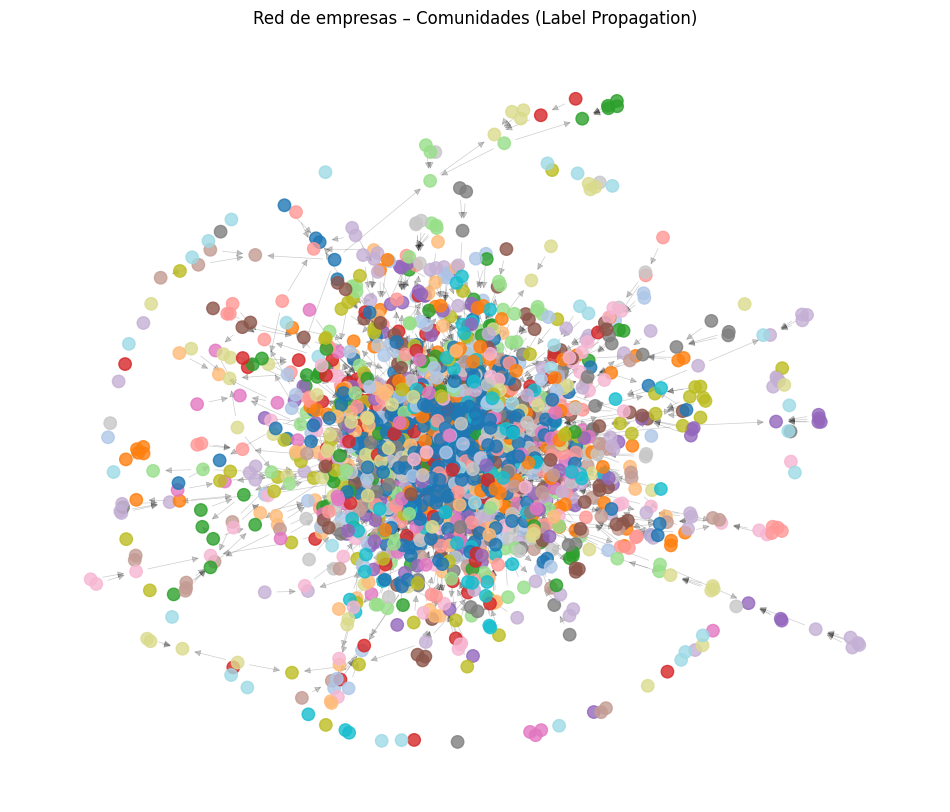

In [17]:
plt.figure(figsize=(12, 10))

# Posición de los nodos
pos = nx.spring_layout(G, seed=42)

# Colores según comunidad
communities_ids = [G.nodes[n]["community"] for n in G.nodes()]

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=communities_ids,
    cmap=plt.cm.tab20,
    node_size=80,
    alpha=0.8
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2,
    width=0.5
)

plt.title("Red de empresas – Comunidades (Label Propagation)")
plt.axis("off")
plt.show()


La visualización de la red revela una estructura con un núcleo central densamente conectado y múltiples comunidades periféricas de menor tamaño. Esta configuración sugiere la coexistencia de un grupo amplio de empresas con características compartidas y varios clusters especializados, con fronteras difusas entre comunidades. Dicho patrón es consistente con un ecosistema empresarial donde la información circula entre grupos, reduciendo las asimetrías informacionales.

In [20]:
community_sizes = {i: len(c) for i, c in enumerate(communities)}
community_sizes

for k, v in sorted(community_sizes.items(), key=lambda x: x[1], reverse=True):
    print(f"Comunidad {k}: {v} nodos")


Comunidad 4: 185 nodos
Comunidad 10: 94 nodos
Comunidad 11: 56 nodos
Comunidad 23: 50 nodos
Comunidad 1: 42 nodos
Comunidad 25: 30 nodos
Comunidad 61: 29 nodos
Comunidad 37: 21 nodos
Comunidad 31: 19 nodos
Comunidad 0: 16 nodos
Comunidad 15: 15 nodos
Comunidad 104: 15 nodos
Comunidad 7: 12 nodos
Comunidad 22: 11 nodos
Comunidad 84: 10 nodos
Comunidad 2: 9 nodos
Comunidad 5: 9 nodos
Comunidad 12: 9 nodos
Comunidad 62: 9 nodos
Comunidad 63: 9 nodos
Comunidad 35: 8 nodos
Comunidad 44: 8 nodos
Comunidad 55: 8 nodos
Comunidad 65: 8 nodos
Comunidad 148: 8 nodos
Comunidad 216: 8 nodos
Comunidad 428: 8 nodos
Comunidad 170: 7 nodos
Comunidad 171: 7 nodos
Comunidad 176: 7 nodos
Comunidad 217: 7 nodos
Comunidad 328: 7 nodos
Comunidad 69: 6 nodos
Comunidad 71: 6 nodos
Comunidad 72: 6 nodos
Comunidad 79: 6 nodos
Comunidad 88: 6 nodos
Comunidad 89: 6 nodos
Comunidad 103: 6 nodos
Comunidad 120: 6 nodos
Comunidad 145: 6 nodos
Comunidad 152: 6 nodos
Comunidad 156: 6 nodos
Comunidad 163: 6 nodos
Comunid

In [24]:
mod = modularity(G, communities)
print(f"Modularidad: {mod:.4f}")


Modularidad: 0.4430


In [26]:
# Create a DataFrame from the graph's node attributes
df_nodes_attributes = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient='index')

# Separate the 'community' column (which is an integer ID for grouping)
community_labels = df_nodes_attributes['community']

# Select only the *other* numeric columns for which we want to compute the mean
# We drop 'community' first to ensure it's not included in the mean calculation, as it's an ID.
numeric_columns_for_mean = df_nodes_attributes.drop(columns=['community'], errors='ignore').select_dtypes(include='number')

# Combine 'community' labels with the numeric attributes for grouping and aggregation
df_for_community_profile = pd.concat([community_labels, numeric_columns_for_mean], axis=1)

# Group by the 'community' and calculate the mean of the other numeric attributes
community_profile = df_for_community_profile.groupby('community').mean()

print(community_profile)

           Number of Investments  Number of Lead Investments  \
community                                                      
0                      74.187500                   60.636364   
1                      75.536585                   54.875000   
2                      58.777778                   28.666667   
3                      45.000000                   32.000000   
4                      78.612362                   75.414894   
...                          ...                         ...   
561                     4.000000                    1.000000   
562                     0.000000                         NaN   
563                     1.000000                         NaN   
564                     0.000000                         NaN   
565                     1.000000                         NaN   

           Number of Diversity Investments  Number of Exits  \
community                                                     
0                                 8.40000

In [28]:
all_communities = [G.nodes[node]['community'] for node in G.nodes() if 'community' in G.nodes[node]]
unique_communities = sorted(list(set(all_communities)))

for c in unique_communities:
    nodes_c = [node for node, data in G.nodes(data=True) if data.get('community') == c]
    subgraph = G_undirected.subgraph(nodes_c)

    n_nodes = subgraph.number_of_nodes()
    # Avoid division by zero for empty subgraphs
    if n_nodes == 0:
        print(f"\nComunidad {c} (vacía)")
        print("Nodos: 0")
        print("Aristas: 0")
        print("Densidad: 0.0")
        print("Grado promedio: 0.0")
        continue

    n_edges = subgraph.number_of_edges()
    density = nx.density(subgraph)
    avg_degree = sum(dict(subgraph.degree()).values()) / n_nodes

    print(f"\nComunidad {c}")
    print("Nodos:", n_nodes)
    print("Aristas:", n_edges)
    print("Densidad:", round(density,4))
    print("Grado promedio:", round(avg_degree,4))


Comunidad 0
Nodos: 16
Aristas: 18
Densidad: 0.15
Grado promedio: 2.25

Comunidad 1
Nodos: 42
Aristas: 51
Densidad: 0.0592
Grado promedio: 2.4286

Comunidad 2
Nodos: 9
Aristas: 9
Densidad: 0.25
Grado promedio: 2.0

Comunidad 3
Nodos: 2
Aristas: 1
Densidad: 1.0
Grado promedio: 1.0

Comunidad 4
Nodos: 185
Aristas: 316
Densidad: 0.0186
Grado promedio: 3.4162

Comunidad 5
Nodos: 9
Aristas: 8
Densidad: 0.2222
Grado promedio: 1.7778

Comunidad 6
Nodos: 2
Aristas: 1
Densidad: 1.0
Grado promedio: 1.0

Comunidad 7
Nodos: 12
Aristas: 12
Densidad: 0.1818
Grado promedio: 2.0

Comunidad 8
Nodos: 4
Aristas: 3
Densidad: 0.5
Grado promedio: 1.5

Comunidad 9
Nodos: 2
Aristas: 1
Densidad: 1.0
Grado promedio: 1.0

Comunidad 10
Nodos: 94
Aristas: 182
Densidad: 0.0416
Grado promedio: 3.8723

Comunidad 11
Nodos: 56
Aristas: 73
Densidad: 0.0474
Grado promedio: 2.6071

Comunidad 12
Nodos: 9
Aristas: 8
Densidad: 0.2222
Grado promedio: 1.7778

Comunidad 13
Nodos: 3
Aristas: 2
Densidad: 0.6667
Grado promedio: 1.

La modularidad obtenida (0.2609) indica la presencia de una estructura comunitaria moderada en la red, lo que sugiere que las empresas tienden a agruparse según características compartidas, aunque sin una segmentación rígida. Este resultado es consistente con un ecosistema de inversión donde la información fluye entre comunidades y los actores participan en múltiples contextos sectoriales.

### Fluid communities

In [ ]:
k = len(communities)

# Convert the directed graph to an undirected graph for Fluid Communities
G_undirected_fluid = G.to_undirected()

# Check if the graph is connected. If not, use the largest connected component.
if not nx.is_connected(G_undirected_fluid):
    largest_cc = max(nx.connected_components(G_undirected_fluid), key=len)
    G_undirected_fluid_cc = G_undirected_fluid.subgraph(largest_cc).copy()
    print("Graph is not connected. Using the largest connected component for Fluid Communities.")
else:
    G_undirected_fluid_cc = G_undirected_fluid

# Ejecutar Fluid Communities on the connected component
fluid_communities = nx.algorithms.community.asyn_fluidc(G_undirected_fluid_cc, k)

# Convertir a lista
fluid_communities = list(fluid_communities)

print(f"Número de comunidades (Fluid): {len(fluid_communities)}")

Graph is not connected. Using the largest connected component for Fluid Communities.
Número de comunidades (Fluid): 266


In [ ]:
mod_fluid = modularity(G_undirected_fluid_cc, fluid_communities)
print(f"Modularidad (Fluid Communities): {mod_fluid:.4f}")

Modularidad (Fluid Communities): 0.4493


In [ ]:
# Crear diccionario nodo -> comunidad (Fluid)
node_community_fluid = {}

for i, community in enumerate(fluid_communities):
    for node in community:
        node_community_fluid[node] = i

# Guardar como atributo en el componente conectado
nx.set_node_attributes(G_undirected_fluid_cc, node_community_fluid, "community_fluid")

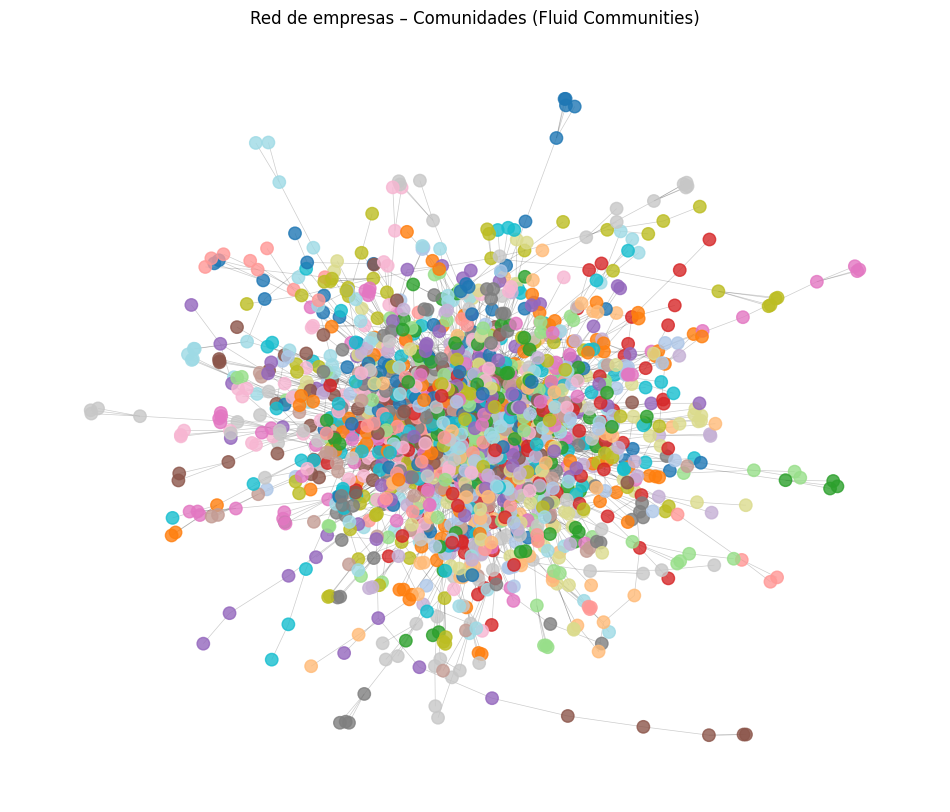

In [ ]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G_undirected_fluid_cc, seed=42)

# Get node colors only for nodes in the connected component
colors_fluid = [G_undirected_fluid_cc.nodes[n]["community_fluid"] for n in G_undirected_fluid_cc.nodes()]

nx.draw_networkx_nodes(
    G_undirected_fluid_cc, # Use the connected component graph
    pos,
    node_color=colors_fluid,
    cmap=plt.cm.tab20,
    node_size=80,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_undirected_fluid_cc, # Use the connected component graph
    pos,
    alpha=0.2,
    width=0.5
)

plt.title("Red de empresas – Comunidades (Fluid Communities)")
plt.axis("off")
plt.show()

In [ ]:


# Get the nodes that are part of the largest connected component, as fluid_communities were calculated on it.
# We will compare the communities only for these common nodes.
nodes_for_comparison = list(G_undirected_fluid_cc.nodes())

# Get the Label Propagation communities for these specific nodes from the original graph G
labels_lp = [G.nodes[n]["community"] for n in nodes_for_comparison]

# Get the Fluid Communities communities for these specific nodes from the connected component graph
labels_fluid = [G_undirected_fluid_cc.nodes[n]["community_fluid"] for n in nodes_for_comparison]

nmi = normalized_mutual_info_score(labels_lp, labels_fluid)
print(f"NMI entre LP y Fluid (para nodos en el componente conectado principal): {nmi:.3f}")

NMI entre LP y Fluid (para nodos en el componente conectado principal): 0.529


La similitud entre las particiones obtenidas mediante Label Propagation y Fluid Communities, medida a través del índice de información mutua normalizada (NMI = 0.528), indica una consistencia moderada entre ambos métodos. Este resultado sugiere que, si bien los algoritmos identifican una estructura comunitaria subyacente común, difieren en la delimitación de sus fronteras, reflejando la coexistencia de integración y segmentación en la red.

 ### Método de Louvain

In [ ]:
R = nx.to_undirected(G)

partition = cl.best_partition(R, random_state=10)
comLouvain = len(set(partition.values()))
print(f'Se identifican {comLouvain} comunidades')
modularidad = cl.modularity(partition, R)
print(f'Modularidad (Louvain): {modularidad:.4f}')

Se identifican 37 comunidades
Modularidad (Louvain): 0.5799


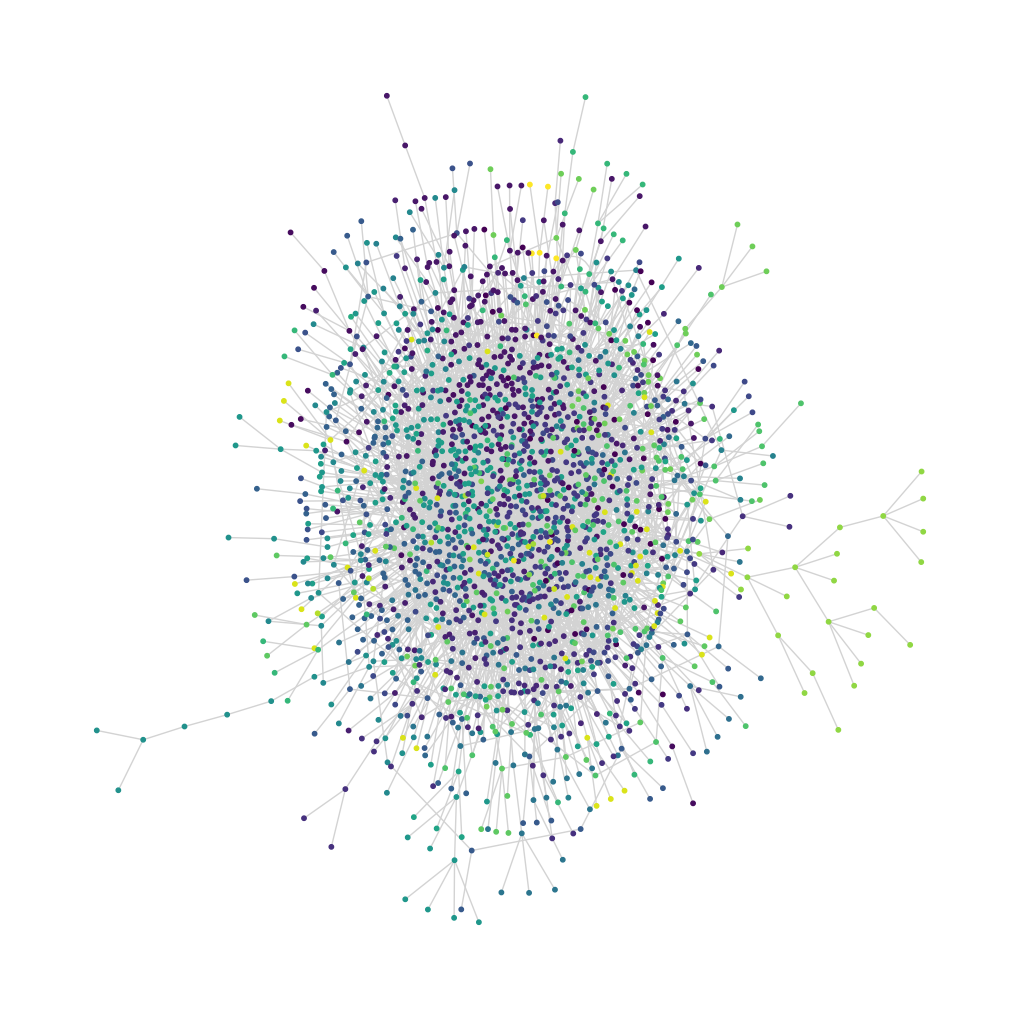

In [ ]:
# Definir lienzo
fig=plt.figure(figsize=(10,10))

# Guardar posiciones
pos = nx.kamada_kawai_layout(R)

# Graficar
nx.draw(R, pos=pos, node_size=10, node_color=list(partition.values()),edge_color='lightgray')

# Mostrar gráfica
plt.show()

En este trabajo se aplicó el algoritmo de Louvain para la detección de comunidades en la red analizada, debido a su capacidad para identificar particiones de manera eficiente en grafos de gran tamaño mediante la optimización de la modularidad. A diferencia de otros métodos evaluados, como Label Propagation y Fluid Communities, Louvain no requiere fijar previamente el número de comunidades y produce una partición emergente basada en la estructura topológica del grafo. El resultado obtenido identifica 37 comunidades con una modularidad de 0.5799, valor que indica una estructura comunitaria bien definida, caracterizada por una alta densidad de conexiones internas y una separación significativa entre comunidades. Esta combinación de estabilidad, escalabilidad y una métrica objetiva como la modularidad justifica la elección de Louvain como uno de los métodos más adecuados para el análisis de comunidades en esta red.